# Phase 5: Inference and Explainability

This notebook demonstrates how to load the best-performing trained model, run inference on new subject-level feature vectors, and perform model-agnostic feature importance analysis using permutation importance.

### Imports and Workspace Setup

In [1]:
import sys
import os
from pathlib import Path

# Change working directory to project root if running from notebooks directory
if Path.cwd().name == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import Image, display

from src.inference import run_inference
from src.explainability import generate_permutation_importance

print("Workspace directory:", os.getcwd())

Workspace directory: /Users/arvindpadala/Documents/projects/NeuroFeatureLab


### Subject-Level Inference

We run inference on two simulated subject feature vectors: a low-risk profile and a high-risk profile.

In [2]:
high_risk_result = run_inference("data/sample_subject_high_risk.json")
print("High-Risk Subject Inference:")
print(f"  Prediction: {high_risk_result['prediction_text']}")
print(f"  PTE-like probability: {high_risk_result['pte_like_probability']:.4f}")

High-Risk Subject Inference:
  Prediction: PTE-like feature pattern
  PTE-like probability: 1.0000


In [3]:
low_risk_result = run_inference("data/sample_subject_low_risk.json")
print("Low-Risk Subject Inference:")
print(f"  Prediction: {low_risk_result['prediction_text']}")
print(f"  PTE-like probability: {low_risk_result['pte_like_probability']:.4f}")

Low-Risk Subject Inference:
  Prediction: non-PTE-like feature pattern
  PTE-like probability: 0.0000


### Feature Importance Analysis

We calculate model-agnostic feature importances on the test set using permutation importance. Permutation importance measures the drop in the model's test performance (ROC AUC) when a feature's values are shuffled.

In [4]:
importance_df = generate_permutation_importance(
    data_path="data/simulated_pte_features.csv",
    model_path="models/best_model.pkl",
    output_path="outputs/feature_importance.png",
    top_n=12
)

In [5]:
print("Top Feature Importances (ROC AUC Drop):")
display(importance_df.head(12))

Top Feature Importances (ROC AUC Drop):


,feature,importance_mean,importance_std
0,right_temporal_lesion_volume,0.027389,0.012344
1,left_temporal_lesion_volume,0.015889,0.009970
8,right_occipital_alff,0.014389,0.004785
3,left_occipital_lesion_volume,0.012556,0.009422
2,right_occipital_lesion_volume,0.011444,0.006422
6,right_temporal_alff,0.010056,0.005205
12,temporal_cerebellum_connectivity,0.009889,0.003815
7,left_temporal_alff,0.007611,0.003483
11,temporal_occipital_connectivity,0.007611,0.005636
4,cerebellum_lesion_volume,0.007500,0.005257


Permutation Importance Plot:


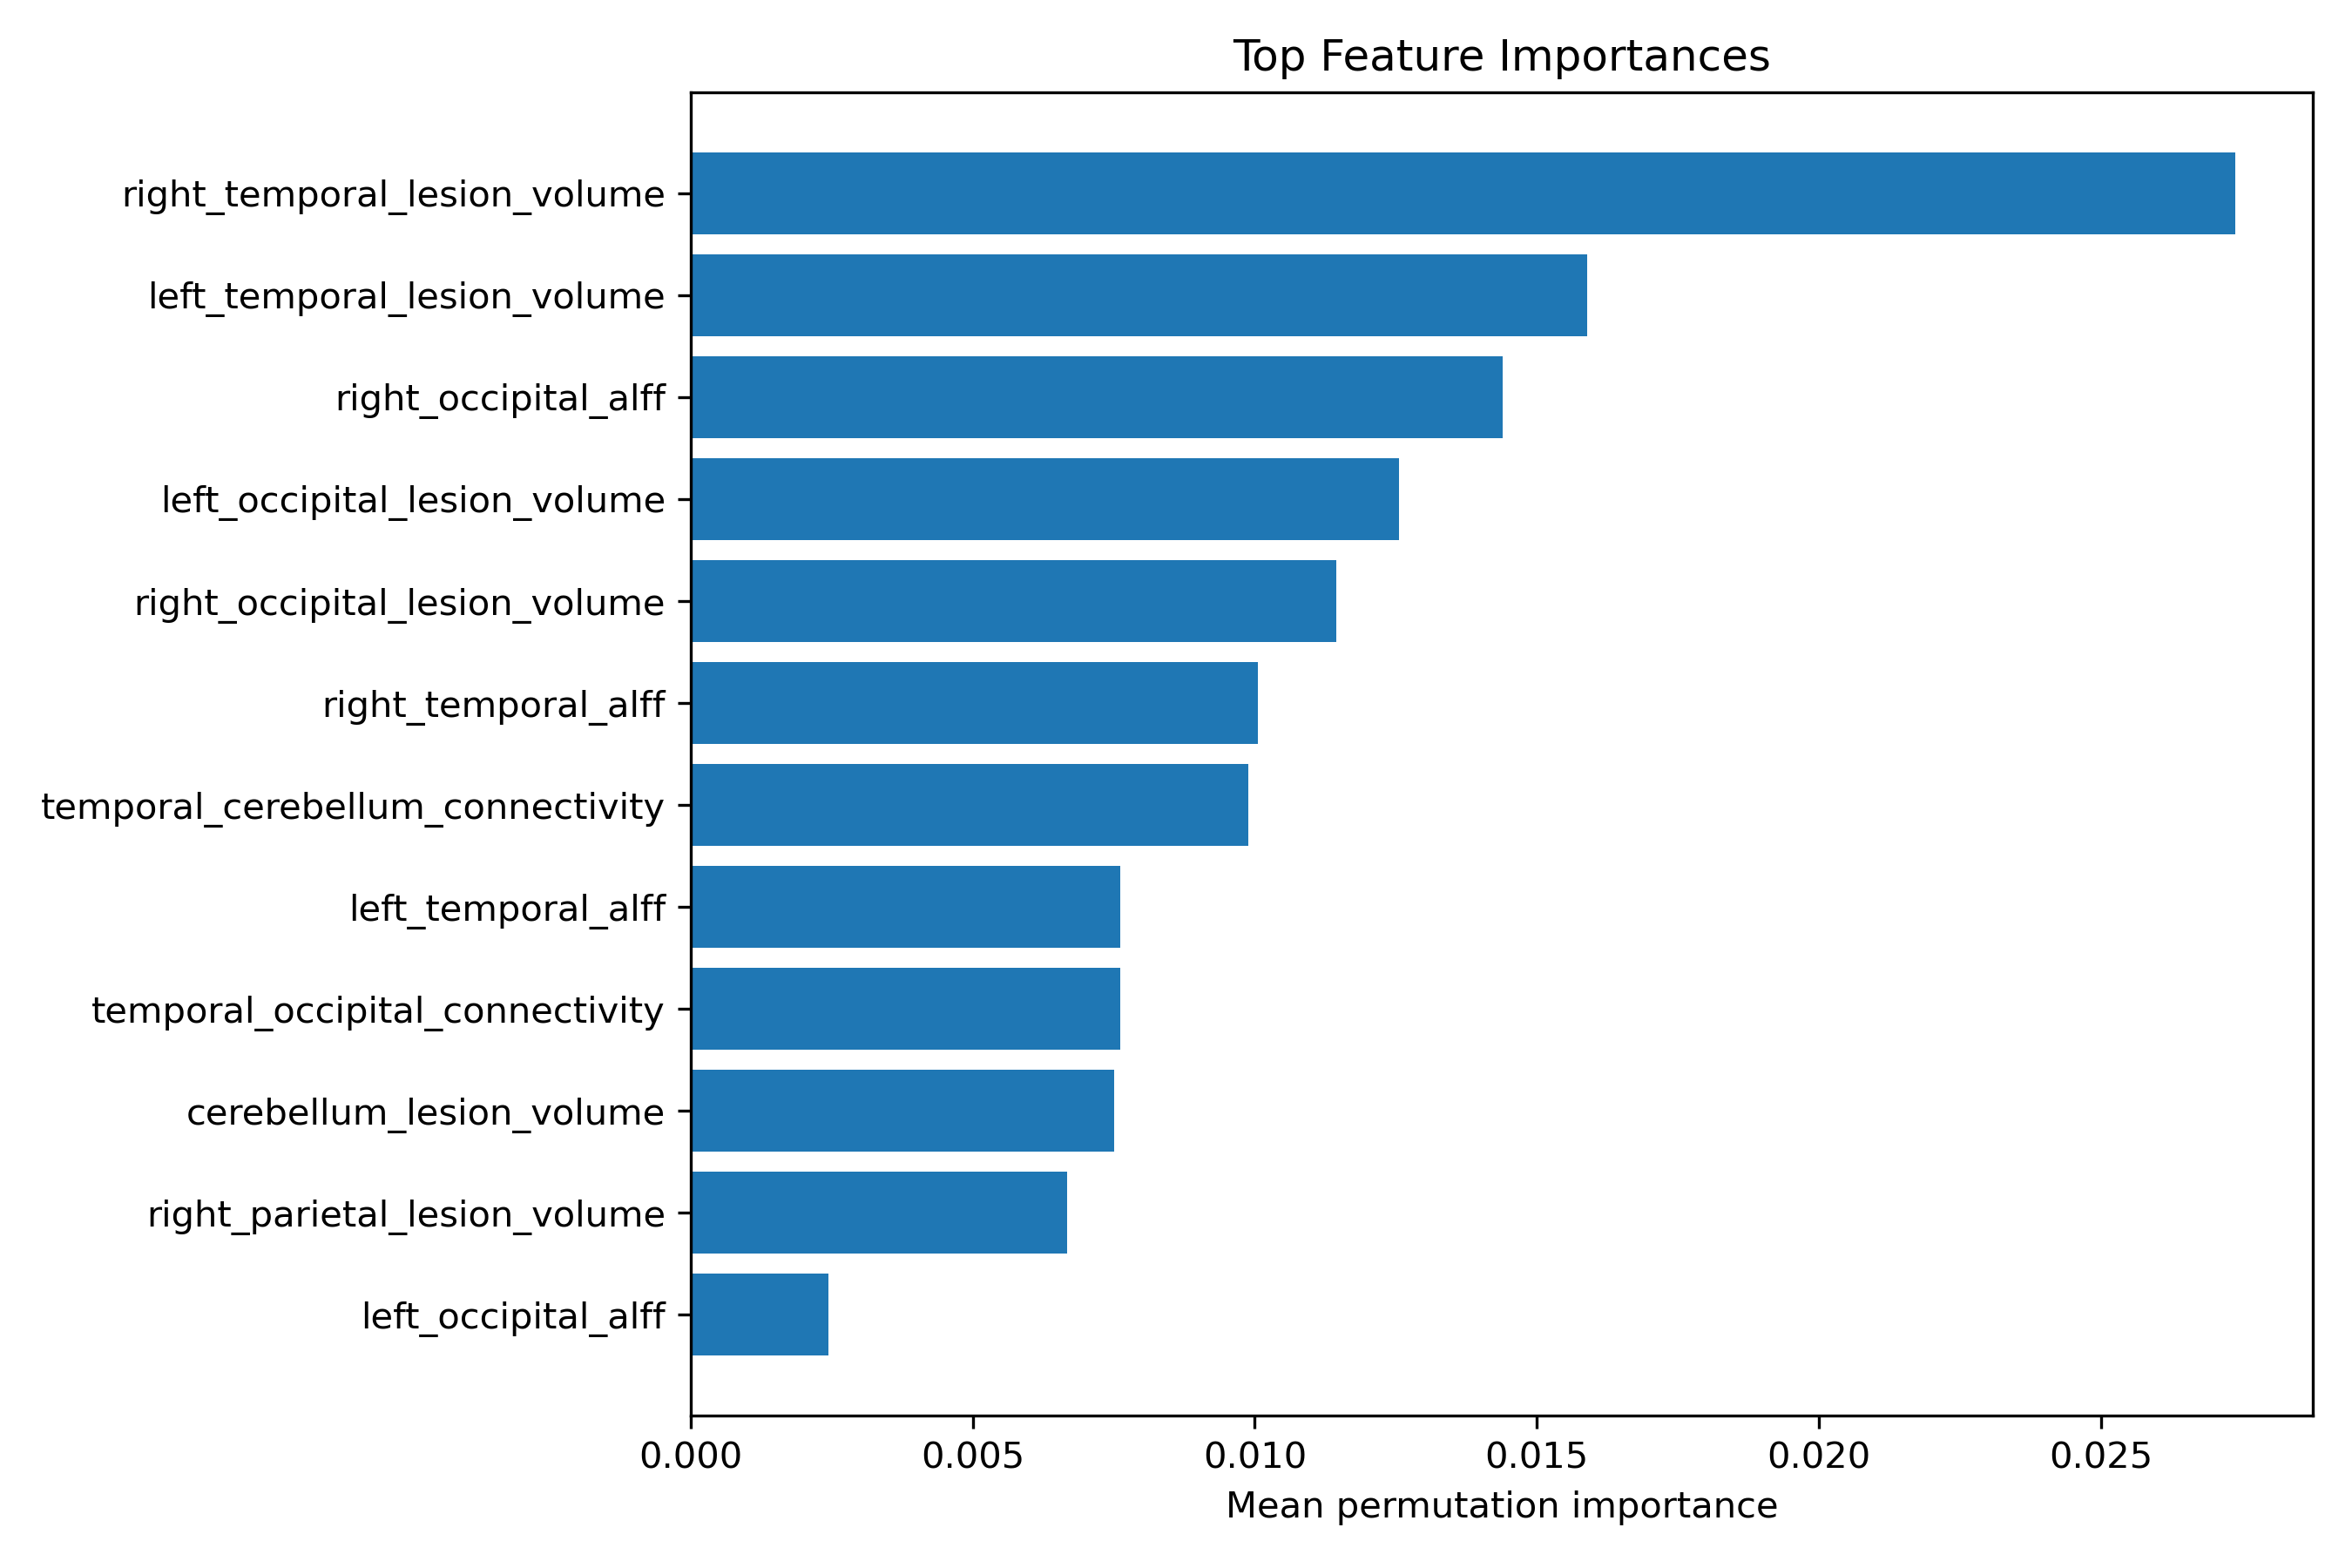

In [6]:
print("Permutation Importance Plot:")
display(Image(filename="outputs/feature_importance.png"))